In [59]:
import pandas as pd
import os

# Шлях до ваших сирих даних (змініть на свій, якщо він інший)
DATA_PATH = "C:/University/6 grade/Diploma/AniDB 2020/"

In [60]:
# 1. Завантаження файлів
# Припускаємо, що файли лежать у папці
df_anime = pd.read_csv(os.path.join(DATA_PATH, 'anime.csv'))
df_synopsis = pd.read_csv(os.path.join(DATA_PATH, 'anime_with_synopsis.csv'))

In [61]:
# 2. Огляд структури (перші кілька рядків)
print(f"Розмір основної таблиці: {df_anime.shape}")
print(f"Розмір таблиці з синопсисами: {df_synopsis.shape}")

Розмір основної таблиці: (17562, 35)
Розмір таблиці з синопсисами: (16214, 5)


In [62]:
# 3. Виведення назв колонок
print("Колонки df_anime:", df_anime.columns.tolist())
print("Колонки df_synopsis:", df_synopsis.columns.tolist())

Колонки df_anime: ['MAL_ID', 'Name', 'Score', 'Genres', 'English name', 'Japanese name', 'Type', 'Episodes', 'Aired', 'Premiered', 'Producers', 'Licensors', 'Studios', 'Source', 'Duration', 'Rating', 'Ranked', 'Popularity', 'Members', 'Favorites', 'Watching', 'Completed', 'On-Hold', 'Dropped', 'Plan to Watch', 'Score-10', 'Score-9', 'Score-8', 'Score-7', 'Score-6', 'Score-5', 'Score-4', 'Score-3', 'Score-2', 'Score-1']
Колонки df_synopsis: ['MAL_ID', 'Name', 'Score', 'Genres', 'sypnopsis']


In [63]:
# Перейменування колонки 'sypnopsis' на 'synopsis'
df_synopsis = df_synopsis.rename(columns={'sypnopsis': 'synopsis'})

In [64]:
print("Колонки df_synopsis:", df_synopsis.columns.tolist())

Колонки df_synopsis: ['MAL_ID', 'Name', 'Score', 'Genres', 'synopsis']


In [65]:
# 4. Перевірка пропусків та заглушок у колонці 'synopsis'
total_rows = len(df_synopsis)

# Заглушка 1
placeholder1 = "No synopsis has been added for this series yet. Click here to update this information."
count1 = (df_synopsis['synopsis'] == placeholder1).sum()
percent1 = (count1 / total_rows) * 100

# Заглушка 2
placeholder2 = "No synopsis information has been added to this title. Help improve our database by adding a synopsis here ."
count2 = (df_synopsis['synopsis'] == placeholder2).sum()
percent2 = (count2 / total_rows) * 100

# Пропуски (NaN)
nan_count = df_synopsis['synopsis'].isnull().sum()
nan_percent = (nan_count / total_rows) * 100

print(f"Заглушка 1: {count1} записів ({percent1:.2f}%)")
print(f"Заглушка 2: {count2} записів ({percent2:.2f}%)")
print(f"Пропуски: {nan_count} записів ({nan_percent:.2f}%)")

Заглушка 1: 35 записів (0.22%)
Заглушка 2: 709 записів (4.37%)
Пропуски: 8 записів (0.05%)


In [66]:
df_synopsis.loc[df_synopsis['synopsis'] == placeholder1, 'synopsis'] = None
df_synopsis.loc[df_synopsis['synopsis'] == placeholder2, 'synopsis'] = None

# Перевірка після заміни
nan_count_after = df_synopsis['synopsis'].isnull().sum()
nan_percent_after = (nan_count_after / total_rows) * 100

print(f"Пропуски після заміни: {nan_count_after} записів ({nan_percent_after:.2f}%)")

Пропуски після заміни: 752 записів (4.64%)


In [67]:
# 5. Перевірка співвідношення між df_anime та df_synopsis за MAL_ID
anime_ids = set(df_anime['MAL_ID'])
synopsis_ids = set(df_synopsis['MAL_ID'])

# Аніме у df_synopsis, але не у df_anime
only_in_synopsis = synopsis_ids - anime_ids
count_only_synopsis = len(only_in_synopsis)
percent_only_synopsis = (count_only_synopsis / len(synopsis_ids)) * 100

# Аніме у df_anime, але не у df_synopsis
only_in_anime = anime_ids - synopsis_ids
count_only_anime = len(only_in_anime)
percent_only_anime = (count_only_anime / len(anime_ids)) * 100

# Спільні аніме
common_ids = anime_ids & synopsis_ids
count_common = len(common_ids)

print(f"Всього у df_anime: {len(anime_ids)}")
print(f"Всього у df_synopsis: {len(synopsis_ids)}")
print(f"Спільних аніме: {count_common}")
print(f"\nТільки у df_synopsis: {count_only_synopsis} записів ({percent_only_synopsis:.2f}%)")
print(f"Тільки у df_anime: {count_only_anime} записів ({percent_only_anime:.2f}%)")

Всього у df_anime: 17562
Всього у df_synopsis: 16214
Спільних аніме: 16214

Тільки у df_synopsis: 0 записів (0.00%)
Тільки у df_anime: 1348 записів (7.68%)


In [68]:
# 6. Перевірка та видалення дуплікатів
anime_dup_count = df_anime.duplicated().sum()
synopsis_dup_count = df_synopsis.duplicated().sum()

print(f"Повні дуплікатні рядки в df_anime: {anime_dup_count}")
print(f"Повні дуплікатні рядки в df_synopsis: {synopsis_dup_count}")

df_anime = df_anime.drop_duplicates()
df_synopsis = df_synopsis.drop_duplicates()

print(f"Після видалення: df_anime = {len(df_anime)} рядків, df_synopsis = {len(df_synopsis)} рядків")

Повні дуплікатні рядки в df_anime: 0
Повні дуплікатні рядки в df_synopsis: 0
Після видалення: df_anime = 17562 рядків, df_synopsis = 16214 рядків


In [69]:
anime_dup_by_id = df_anime.duplicated(subset=['MAL_ID']).sum()
print(f"Дуплікатні MAL_ID в df_anime: {anime_dup_by_id}")

synopsis_dup_by_id = df_synopsis.duplicated(subset=['MAL_ID']).sum()
print(f"Дуплікатні MAL_ID в df_synopsis: {synopsis_dup_by_id}")

Дуплікатні MAL_ID в df_anime: 0
Дуплікатні MAL_ID в df_synopsis: 0


In [70]:
# 7. Перевірка збігу даних між df_anime та df_synopsis за MAL_ID
# Об'єднаємо датафрейми за MAL_ID
df_merged = pd.merge(df_synopsis[['MAL_ID', 'Name', 'Score', 'Genres']], 
                      df_anime[['MAL_ID', 'Name', 'Score', 'Genres']], 
                      on='MAL_ID', 
                      suffixes=('_synopsis', '_anime'),
                      how='inner')

# Перевіримо, чи збігаються значення
name_mismatch = (df_merged['Name_synopsis'] != df_merged['Name_anime']).sum()
score_mismatch = (df_merged['Score_synopsis'] != df_merged['Score_anime']).sum()
genres_mismatch = (df_merged['Genres_synopsis'] != df_merged['Genres_anime']).sum()

print(f"Розбіжності в Name: {name_mismatch} записів")
print(f"Розбіжності в Score: {score_mismatch} записів")
print(f"Розбіжності в Genres: {genres_mismatch} записів")

# Виведемо приклади розбіжностей для Name
if name_mismatch > 0:
    print("\nПриклади розбіжностей в Name:")
    print(df_merged[df_merged['Name_synopsis'] != df_merged['Name_anime']][['MAL_ID', 'Name_synopsis', 'Name_anime']].head())

# Виведемо приклади розбіжностей для Score
if score_mismatch > 0:
    print("\nПриклади розбіжностей в Score:")
    print(df_merged[df_merged['Score_synopsis'] != df_merged['Score_anime']][['MAL_ID', 'Score_synopsis', 'Score_anime']].head())

# Виведемо приклади розбіжностей для Genres
if genres_mismatch > 0:
    print("\nПриклади розбіжностей в Genres:")
    print(df_merged[df_merged['Genres_synopsis'] != df_merged['Genres_anime']][['MAL_ID', 'Genres_synopsis', 'Genres_anime']].head())

Розбіжності в Name: 0 записів
Розбіжності в Score: 0 записів
Розбіжності в Genres: 0 записів


In [71]:
# 8. Додавання синопсисів до df_anime
# Створимо словник MAL_ID -> synopsis з df_synopsis
synopsis_dict = dict(zip(df_synopsis['MAL_ID'], df_synopsis['synopsis']))

# Додамо нову колонку з синопсисами (NaN для аніме, яких нема в df_synopsis)
df_anime['synopsis'] = df_anime['MAL_ID'].map(synopsis_dict)

# Перевірка кількості NaN у синопсисах
total_anime = len(df_anime)
nan_count_synopsis = df_anime['synopsis'].isnull().sum()
nan_percent_synopsis = (nan_count_synopsis / total_anime) * 100

print(f"Всього аніме в df_anime: {total_anime}")
print(f"NaN у колонці synopsis: {nan_count_synopsis} записів ({nan_percent_synopsis:.2f}%)")
print(f"З синопсисами: {total_anime - nan_count_synopsis} записів ({100 - nan_percent_synopsis:.2f}%)")

Всього аніме в df_anime: 17562
NaN у колонці synopsis: 2100 записів (11.96%)
З синопсисами: 15462 записів (88.04%)


In [72]:
# 9. Перевірка кількості "Unknown" у колонках імен
name_columns = ['Name', 'English name', 'Japanese name']

print("Перевірка 'Unknown' значень у колонках імен:")
for col in name_columns:
    if col in df_anime.columns:
        unknown_count = (df_anime[col] == 'Unknown').sum()
        unknown_percent = (unknown_count / len(df_anime)) * 100
        nan_count = df_anime[col].isnull().sum()
        nan_percent = (nan_count / len(df_anime)) * 100
        
        print(f"\n{col}:")
        print(f"  Unknown: {unknown_count} записів ({unknown_percent:.2f}%)")
        print(f"  NaN: {nan_count} записів ({nan_percent:.2f}%)")
    else:
        print(f"\n{col}: колонка не знайдена")

Перевірка 'Unknown' значень у колонках імен:

Name:
  Unknown: 0 записів (0.00%)
  NaN: 0 записів (0.00%)

English name:
  Unknown: 10565 записів (60.16%)
  NaN: 0 записів (0.00%)

Japanese name:
  Unknown: 48 записів (0.27%)
  NaN: 0 записів (0.00%)


In [73]:
# 10. Замінити Unknown на NaN у колонці 'English name'
print("Заміна 'Unknown' на NaN у колонці 'English name':")

# Замінити 'Unknown' на None (NaN)
df_anime.loc[df_anime['English name'] == 'Unknown', 'English name'] = None

# Перевірка після заміни
nan_count_after = df_anime['English name'].isnull().sum()
nan_percent_after = (nan_count_after / len(df_anime)) * 100

print(f"NaN після заміни: {nan_count_after} записів ({nan_percent_after:.2f}%)")

Заміна 'Unknown' на NaN у колонці 'English name':
NaN після заміни: 10565 записів (60.16%)


In [74]:
# 11а. Дослідження колонки Score перед конвертацією
print("=== ДОСЛІДЖЕННЯ КОЛОНКИ SCORE ===\n")

# Перевіримо тип даних
print(f"Тип даних: {df_anime['Score'].dtype}")
print(f"Всього записів: {len(df_anime)}\n")

# Подивимось на унікальні значення
print("Кількість унікальних значень:", df_anime['Score'].nunique())
print("\nПерші 20 унікальних значень:")
print(df_anime['Score'].unique()[:20])

# Перевіримо на NaN ДО конвертації
nan_before = df_anime['Score'].isnull().sum()
print(f"\nNaN ДО конвертації: {nan_before} записів")

# Перевіримо на пропуски/порожні рядки
empty_count = (df_anime['Score'] == '').sum()
print(f"Порожні рядки (''):  {empty_count} записів")

# Перевіримо на 'N/A', 'None', тощо
print("\nПоширені значення, які можуть викликати NaN:")
for val in ['N/A', 'None', 'unknown', '-', ' ', 'NA']:
    count = (df_anime['Score'] == val).sum()
    if count > 0:
        print(f"  '{val}': {count} записів")

# Подивимось на значення, які НЕ можна конвертувати в числа
print("\nПриклади значень, які НЕ можна конвертувати:")
test_conversion = pd.to_numeric(df_anime['Score'], errors='coerce')
invalid_mask = test_conversion.isnull() & df_anime['Score'].notna()
invalid_values = df_anime.loc[invalid_mask, 'Score'].unique()
print(invalid_values[:20])
print(f"Всього таких значень: {invalid_mask.sum()}")

=== ДОСЛІДЖЕННЯ КОЛОНКИ SCORE ===

Тип даних: object
Всього записів: 17562

Кількість унікальних значень: 533

Перші 20 унікальних значень:
['8.78' '8.39' '8.24' '7.27' '6.98' '7.95' '8.06' '7.59' '8.15' '8.76'
 '7.91' '8.52' '7.9' '6.38' '7.94' '7.42' '7.76' '7.32' '7.51' '8.32']

NaN ДО конвертації: 0 записів
Порожні рядки (''):  0 записів

Поширені значення, які можуть викликати NaN:

Приклади значень, які НЕ можна конвертувати:
['Unknown']
Всього таких значень: 5141


In [75]:
# 11б. Дослідження аніме з Unknown Score
print("=== ДОСЛІДЖЕННЯ АНІМЕ З UNKNOWN SCORE ===\n")

# Знайдемо рядки з Unknown Score
unknown_score_mask = df_anime['Score'] == 'Unknown'
unknown_score_count = unknown_score_mask.sum()

print(f"Всього аніме з Unknown Score: {unknown_score_count}\n")

# Виведемо перші 10 аніме з Unknown Score та їх деталі
print("Деталі першого аніме з Unknown Score:\n")
unknown_anime_indices = df_anime[unknown_score_mask].index[:10]

for idx in unknown_anime_indices:
    anime = df_anime.loc[idx]
    print(f"MAL_ID: {anime['MAL_ID']} | Name: {anime['Name']}")
    print(f"  Score: {anime['Score']}")
    print(f"  Ranked: {anime['Ranked']}")
    print(f"  Score-10: {anime['Score-10']}")
    print(f"  Score-9: {anime['Score-9']}")
    print(f"  Score-8: {anime['Score-8']}")
    print(f"  Score-7: {anime['Score-7']}")
    print(f"  Score-6: {anime['Score-6']}")
    print(f"  Score-5: {anime['Score-5']}")
    print(f"  Score-4: {anime['Score-4']}")
    print(f"  Score-3: {anime['Score-3']}")
    print(f"  Score-2: {anime['Score-2']}")
    print(f"  Score-1: {anime['Score-1']}")
    print()

=== ДОСЛІДЖЕННЯ АНІМЕ З UNKNOWN SCORE ===

Всього аніме з Unknown Score: 5141

Деталі першого аніме з Unknown Score:

MAL_ID: 1547 | Name: Obake no Q-tarou
  Score: Unknown
  Ranked: 11270.0
  Score-10: 8.0
  Score-9: 5.0
  Score-8: 6.0
  Score-7: 20.0
  Score-6: 28.0
  Score-5: 31.0
  Score-4: 6.0
  Score-3: 6.0
  Score-2: 2.0
  Score-1: 10.0

MAL_ID: 1656 | Name: PostPet Momobin
  Score: Unknown
  Ranked: 11598.0
  Score-10: 7.0
  Score-9: 2.0
  Score-8: 6.0
  Score-7: 13.0
  Score-6: 17.0
  Score-5: 22.0
  Score-4: 15.0
  Score-3: 12.0
  Score-2: 7.0
  Score-1: 10.0

MAL_ID: 1739 | Name: Shibawanko no Wa no Kokoro
  Score: Unknown
  Ranked: 11947.0
  Score-10: 6.0
  Score-9: 4.0
  Score-8: 23.0
  Score-7: 28.0
  Score-6: 18.0
  Score-5: 17.0
  Score-4: 1.0
  Score-3: 3.0
  Score-2: Unknown
  Score-1: 8.0

MAL_ID: 1863 | Name: Silk Road Shounen Yuuto
  Score: Unknown
  Ranked: 12096.0
  Score-10: 3.0
  Score-9: 1.0
  Score-8: 2.0
  Score-7: 9.0
  Score-6: 5.0
  Score-5: 9.0
  Score-4

Аналіз розподілу оцінок (Score):

Оцінки 0: 0 записів (0.00%)
Unknown/NaN: 5141 записів (29.27%)
Дійсних оцінок (1-10): 12421 записів (70.73%)

Розподіл оцінок за діапазонами:
  (0, 1]: 0 записів (0.00% від валідних, 0.00% від всіх)
  (1, 2]: 1 записів (0.01% від валідних, 0.01% від всіх)
  (2, 3]: 12 записів (0.10% від валідних, 0.07% від всіх)
  (3, 4]: 48 записів (0.39% від валідних, 0.27% від всіх)
  (4, 5]: 452 записів (3.64% від валідних, 2.57% від всіх)
  (5, 6]: 2880 записів (23.19% від валідних, 16.40% від всіх)
  (6, 7]: 5284 записів (42.54% від валідних, 30.09% від всіх)
  (7, 8]: 3211 записів (25.85% від валідних, 18.28% від всіх)
  (8, 9]: 524 записів (4.22% від валідних, 2.98% від всіх)
  (9, 10]: 9 записів (0.07% від валідних, 0.05% від всіх)


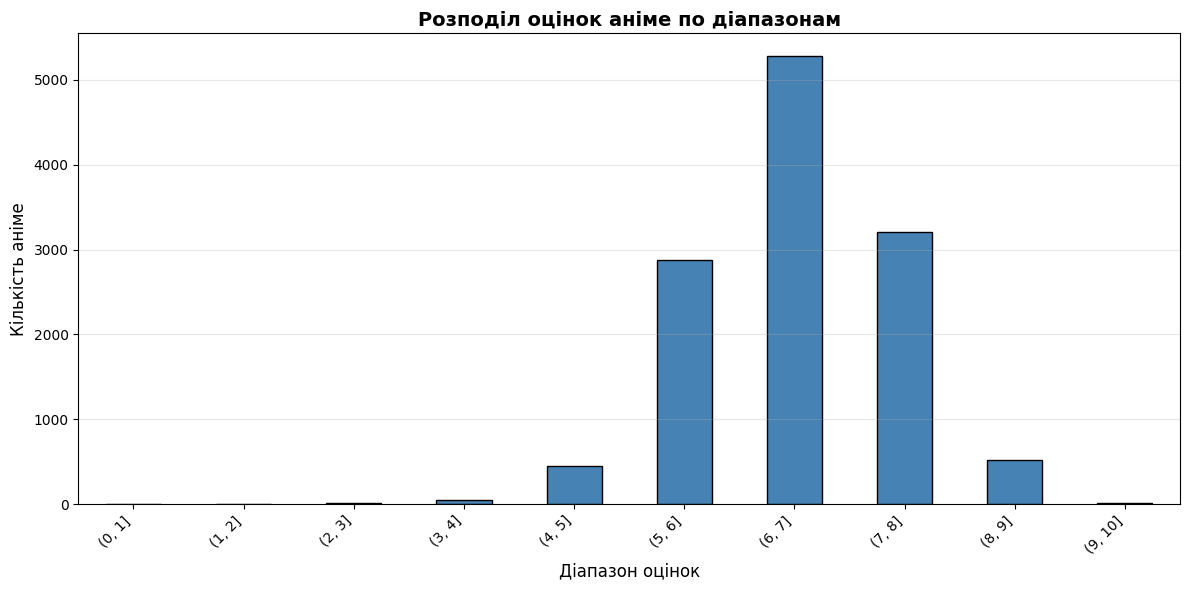

In [76]:
# 11. Аналіз розподілу оцінок (Score)
import matplotlib.pyplot as plt
import numpy as np

print("Аналіз розподілу оцінок (Score):")

# Замінити 'Unknown' на NaN перед конвертацією
df_anime['Score'] = df_anime['Score'].replace('Unknown', np.nan)

# Конвертуємо Score в float
df_anime['Score'] = pd.to_numeric(df_anime['Score'], errors='coerce')

total_anime = len(df_anime)

# Перевірка на 0 та Unknown значення
zero_count = (df_anime['Score'] == 0).sum()
zero_percent = (zero_count / total_anime) * 100

unknown_count = df_anime['Score'].isnull().sum()
unknown_percent = (unknown_count / total_anime) * 100

print(f"\nОцінки 0: {zero_count} записів ({zero_percent:.2f}%)")
print(f"Unknown/NaN: {unknown_count} записів ({unknown_percent:.2f}%)")

# Фільтруємо оцінки від 1 до 10
valid_scores = df_anime[(df_anime['Score'] > 0) & (df_anime['Score'] <= 10)]['Score']
valid_count = len(valid_scores)
valid_percent = (valid_count / total_anime) * 100

print(f"Дійсних оцінок (1-10): {valid_count} записів ({valid_percent:.2f}%)")

# Розбиваємо на 10 діапазонів
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
labels = ['(0, 1]', '(1, 2]', '(2, 3]', '(3, 4]', '(4, 5]', '(5, 6]', '(6, 7]', '(7, 8]', '(8, 9]', '(9, 10]']

score_distribution = pd.cut(valid_scores, bins=bins, labels=labels, right=True)
score_counts = score_distribution.value_counts().sort_index()

print("\nРозподіл оцінок за діапазонами:")
for label, count in score_counts.items():
    percent_range = (count / valid_count) * 100
    percent_total = (count / total_anime) * 100
    print(f"  {label}: {count} записів ({percent_range:.2f}% від валідних, {percent_total:.2f}% від всіх)")

# Побудова діаграми
plt.figure(figsize=(12, 6))
score_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Розподіл оцінок аніме по діапазонам', fontsize=14, fontweight='bold')
plt.xlabel('Діапазон оцінок', fontsize=12)
plt.ylabel('Кількість аніме', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()